In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import  LabelEncoder, StandardScaler


# Models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

# Evaluasi
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import learning_curve

In [2]:
df = pd.read_csv(r'D:\Kitab Suci\Fixxxx belajar\Machine Learning\Dataset\drug200.csv')
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [3]:
df.info()
df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    object 
 2   BP           200 non-null    object 
 3   Cholesterol  200 non-null    object 
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    object 
dtypes: float64(1), int64(1), object(4)
memory usage: 9.5+ KB


(200, 6)

In [4]:
df.isnull().sum()

Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [5]:
df.describe()

,Age,Na_to_K
count,200.000000,200.000000
mean,44.315000,16.084485
std,16.544315,7.223956
min,15.000000,6.269000
25%,31.000000,10.445500
50%,45.000000,13.936500
75%,58.000000,19.380000
max,74.000000,38.247000


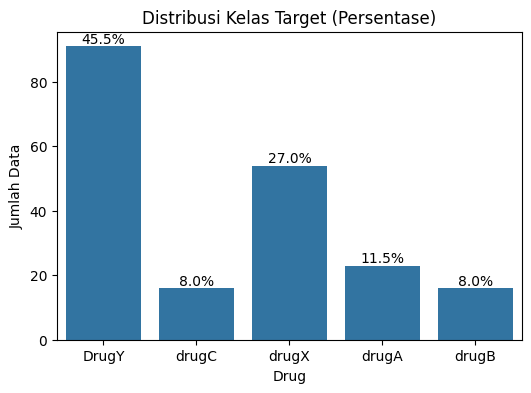

In [6]:
plt.figure(figsize=(6, 4))
ax = sns.countplot(x='Drug', data=df)

total = len(df)
for p in ax.patches:
    count = p.get_height()
    percentage = 100 * count / total
    ax.annotate(
        f'{percentage:.1f}%',
        (p.get_x() + p.get_width() / 2., count),
        ha='center',
        va='bottom'
    )

plt.title("Distribusi Kelas Target (Persentase)")
plt.ylabel("Jumlah Data")
plt.show()

<Axes: title={'center': 'Na_to_K'}, xlabel='Sex', ylabel='count'>

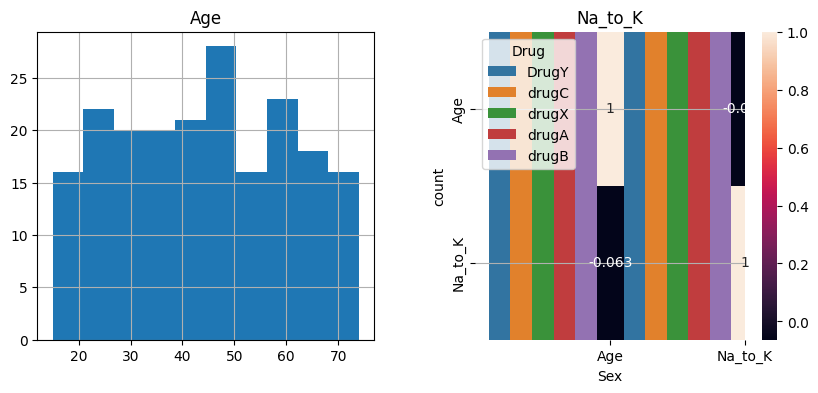

In [7]:
# Distribusi fitur numerik
df[['Age', 'Na_to_K']].hist(figsize=(10, 4))

# Korelasi antar fitur numerik
sns.heatmap(df[['Age', 'Na_to_K']].corr(), annot=True)

# Distribusi fitur kategorikal vs target
sns.countplot(x='Sex', hue='Drug', data=df)

In [8]:
le = LabelEncoder()
df['Sex'] = le.fit_transform(df['Sex'])
df['BP'] = le.fit_transform(df['BP'])          
df['Cholesterol'] = le.fit_transform(df['Cholesterol'])
df['Drug'] = le.fit_transform(df['Drug'])     
df

,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0,0,0,25.355,0
1,47,1,1,0,13.093,3
2,47,1,1,0,10.114,3
3,28,0,2,0,7.798,4
4,61,0,1,0,18.043,0
...,...,...,...,...,...,...
195,56,0,1,0,11.567,3
196,16,1,1,0,12.006,3
197,52,1,2,0,9.894,4
198,23,1,2,1,14.020,4


In [9]:
X = df.drop('Drug', axis=1)
y = df['Drug']

In [10]:
X_train, X_test, Y_train, Y_test = train_test_split (
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

=== Logistic Regression Evaluation ===
Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

           0       0.89      0.89      0.89        18
           1       1.00      1.00      1.00         5
           2       0.75      1.00      0.86         3
           3       1.00      0.67      0.80         3
           4       0.91      0.91      0.91        11

    accuracy                           0.90        40
   macro avg       0.91      0.89      0.89        40
weighted avg       0.91      0.90      0.90        40



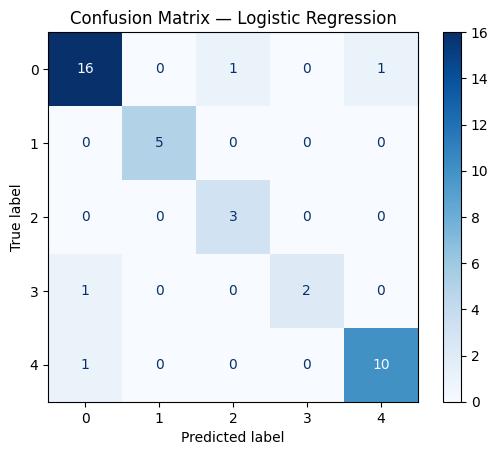

In [11]:
# Logistic Regression
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled, Y_train)

y_pred_log = log_model.predict(X_test_scaled)
print("=== Logistic Regression Evaluation ===")
print("Accuracy:", accuracy_score(Y_test, y_pred_log))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_log))

# Confusion Matrix
cm = confusion_matrix(Y_test, y_pred_log)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=log_model.classes_
)

disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

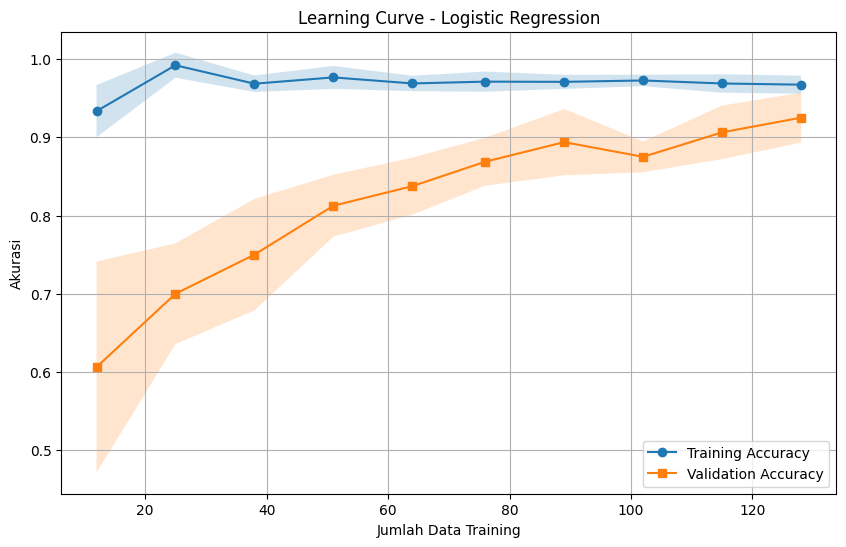

In [12]:
train_sizes, train_scores, val_scores = learning_curve(
    log_model,
    X_train_scaled,
    Y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve - Logistic Regression")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend()
plt.show()

=== KNN Evaluation ===
Accuracy: 0.6

Classification Report:
              precision    recall  f1-score   support

           0       0.56      0.83      0.67        18
           1       0.50      0.20      0.29         5
           2       0.00      0.00      0.00         3
           3       0.00      0.00      0.00         3
           4       0.73      0.73      0.73        11

    accuracy                           0.60        40
   macro avg       0.36      0.35      0.34        40
weighted avg       0.51      0.60      0.54        40



C:\Users\acer\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\acer\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\acer\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is",

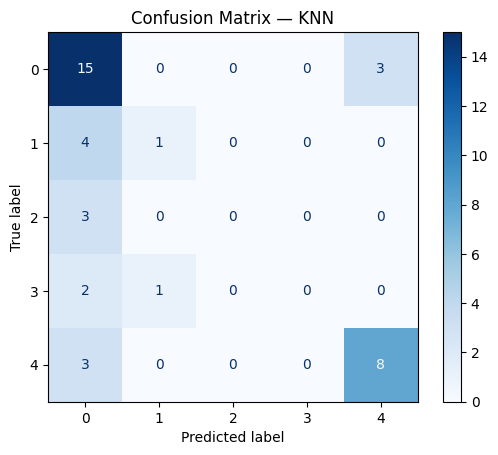

In [13]:
# KNN
knn_model = KNeighborsClassifier(
    n_neighbors=13,
    metric='minkowski'
)

knn_model.fit(X_train_scaled, Y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

print("=== KNN Evaluation ===")
print("Accuracy:", accuracy_score(Y_test, y_pred_knn))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_knn))

# Confusion Matrix
cm_knn = confusion_matrix(Y_test, y_pred_knn)

disp_knn = ConfusionMatrixDisplay(
    confusion_matrix=cm_knn,
    display_labels=knn_model.classes_
)
disp_knn.plot(cmap='Blues')
plt.title("Confusion Matrix — KNN")
plt.show()

C:\Users\acer\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\acer\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "C:\Users\acer\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\acer\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_scorer.py", line 380, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "C:\Users\acer\AppData\Roaming\

C:\Users\acer\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:960: UserWarning: Scoring failed. The score on this train-test partition for these parameters will be set to nan. Details: 
Traceback (most recent call last):
  File "C:\Users\acer\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 949, in _score
    scores = scorer(estimator, X_test, y_test, **score_params)
  File "C:\Users\acer\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_scorer.py", line 288, in __call__
    return self._score(partial(_cached_call, None), estimator, X, y_true, **_kwargs)
           ~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\acer\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_scorer.py", line 380, in _score
    y_pred = method_caller(
        estimator,
    ...<2 lines>...
        pos_label=pos_label,
    )
  File "C:\Users\acer\AppData\Roaming\

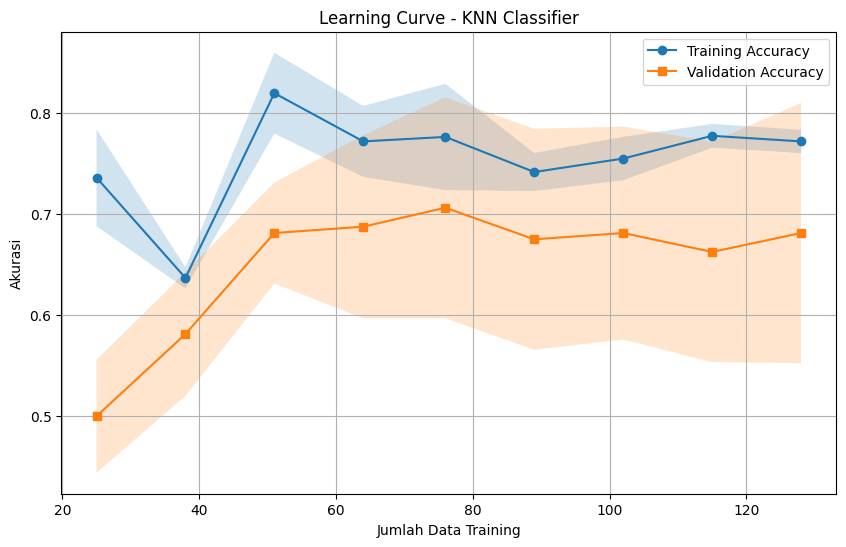

In [14]:
train_sizes, train_scores, val_scores = learning_curve(
    knn_model,
    X_train_scaled,  
    Y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

# Hitung mean dan std
train_mean = train_scores.mean(axis=1)
train_std  = train_scores.std(axis=1)
val_mean   = val_scores.mean(axis=1)
val_std    = val_scores.std(axis=1)

# Plot
plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve - KNN Classifier")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend()
plt.show()

=== Decision Tree Evaluation ===
Accuracy: 0.975

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         3
           3       1.00      1.00      1.00         3
           4       1.00      0.91      0.95        11

    accuracy                           0.97        40
   macro avg       0.99      0.98      0.99        40
weighted avg       0.98      0.97      0.97        40



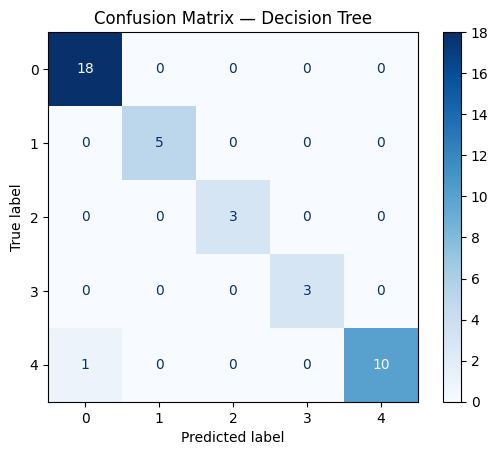

In [15]:
# Decision Tree
dt_model = DecisionTreeClassifier(
    max_depth=4,
    min_samples_split=10,
    min_samples_leaf=5,
    random_state=42
)

dt_model.fit(X_train, Y_train)


y_pred_dt = dt_model.predict(X_test)

print("=== Decision Tree Evaluation ===")
print("Accuracy:", accuracy_score(Y_test, y_pred_dt))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_dt))

# Visualisasi Confusion Matrix
cm = confusion_matrix(Y_test, y_pred_dt)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=dt_model.classes_
)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Decision Tree")
plt.show()

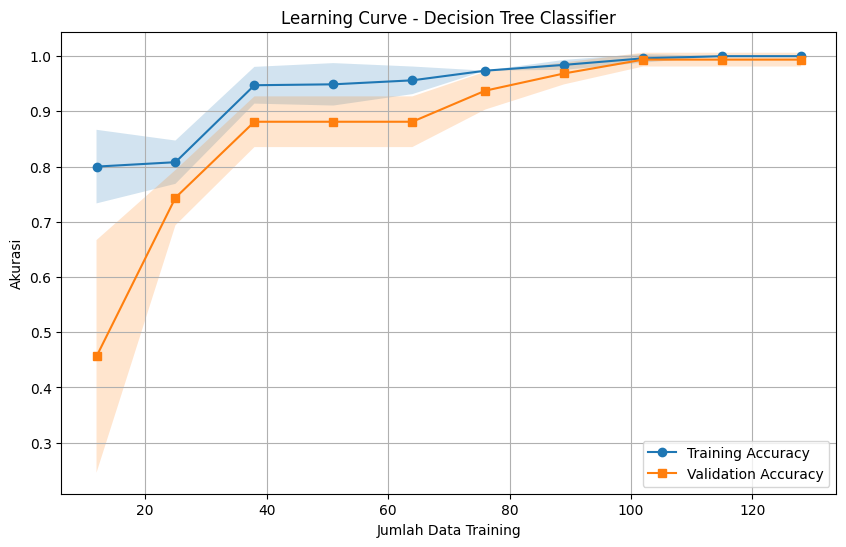

In [16]:
train_sizes, train_scores, val_scores = learning_curve(
    dt_model,
    X_train,
    Y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve - Decision Tree Classifier")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend()
plt.show()

=== Random Forest Evaluation ===
Accuracy: 0.95

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      1.00      1.00         5
           2       1.00      1.00      1.00         3
           3       1.00      0.67      0.80         3
           4       0.91      0.91      0.91        11

    accuracy                           0.95        40
   macro avg       0.97      0.92      0.94        40
weighted avg       0.95      0.95      0.95        40



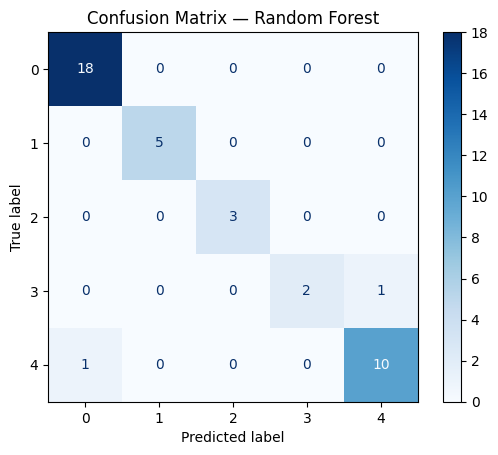

In [17]:
# Random Forest
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=4,
    min_samples_split=12,
    min_samples_leaf=8,
    random_state=42
)

rf_model.fit(X_train, Y_train)


y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest Evaluation ===")
print("Accuracy:", accuracy_score(Y_test, y_pred_rf))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_rf))

# Visualisasi Confusion Matrix
cm = confusion_matrix(Y_test, y_pred_rf)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=rf_model.classes_
)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — Random Forest")
plt.show()

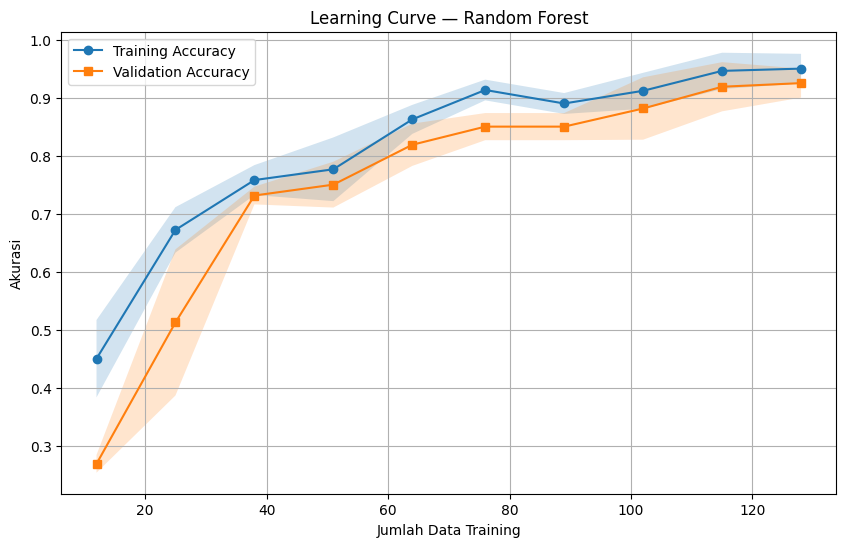

In [18]:
train_sizes, train_scores, val_scores = learning_curve(
    rf_model,
    X_train,
    Y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve — Random Forest")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend()
plt.show()

=== XGBoost Evaluation ===
Accuracy: 0.95

Classification Report:
              precision    recall  f1-score   support

           0       0.95      1.00      0.97        18
           1       1.00      0.80      0.89         5
           2       1.00      1.00      1.00         3
           3       0.75      1.00      0.86         3
           4       1.00      0.91      0.95        11

    accuracy                           0.95        40
   macro avg       0.94      0.94      0.93        40
weighted avg       0.96      0.95      0.95        40



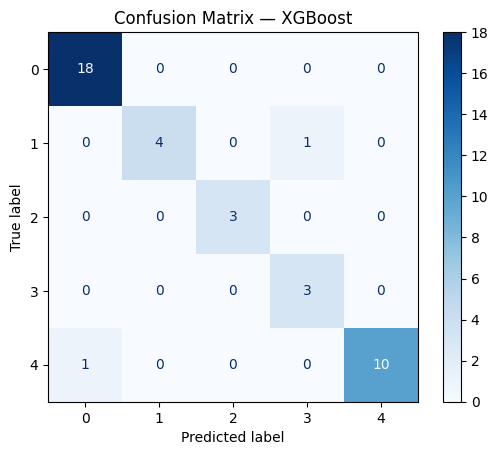

In [19]:
# xgboost
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.7,
    colsample_bytree=0.7,
    reg_alpha=0.1,
    reg_lambda=1.5,
    min_child_weight=5,
    random_state=42
)
xgb_model.fit(X_train, Y_train)

y_pred_xgb = xgb_model.predict(X_test)

print("=== XGBoost Evaluation ===")
print("Accuracy:", accuracy_score(Y_test, y_pred_xgb))
print("\nClassification Report:")   
print(classification_report(Y_test, y_pred_xgb))

# Visualisasi Confusion Matrix
cm = confusion_matrix(Y_test, y_pred_xgb)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=xgb_model.classes_
)
disp.plot(cmap='Blues')
plt.title("Confusion Matrix — XGBoost")
plt.show()

C:\Users\acer\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py:528: FitFailedWarning: 
7 fits failed out of a total of 50.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
1 fits failed with the following error:
Traceback (most recent call last):
  File "C:\Users\acer\AppData\Roaming\Python\Python313\site-packages\sklearn\model_selection\_validation.py", line 866, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\acer\AppData\Roaming\Python\Python313\site-packages\xgboost\core.py", line 774, in inner_f
    return func(**kwargs)
  File "C:\Users\acer\AppData\Roaming\Python\Python313\site-packages\xgboost\sklearn.py", li

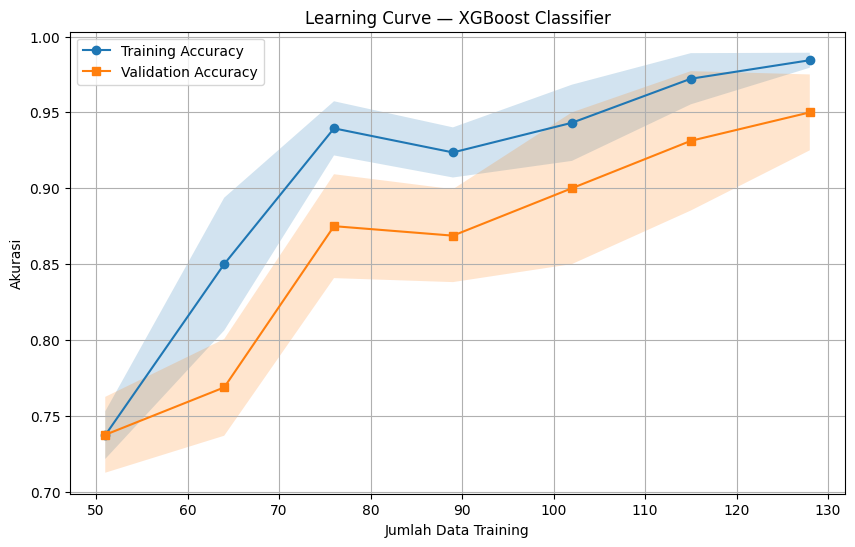

In [20]:
train_sizes, train_scores, val_scores = learning_curve(
    xgb_model,
    X_train,
    Y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve — XGBoost Classifier")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend()
plt.show()

=== SVM Evaluation ===
Accuracy: 0.9

Classification Report:
              precision    recall  f1-score   support

           0       0.94      0.83      0.88        18
           1       1.00      1.00      1.00         5
           2       1.00      0.67      0.80         3
           3       1.00      1.00      1.00         3
           4       0.79      1.00      0.88        11

    accuracy                           0.90        40
   macro avg       0.94      0.90      0.91        40
weighted avg       0.91      0.90      0.90        40



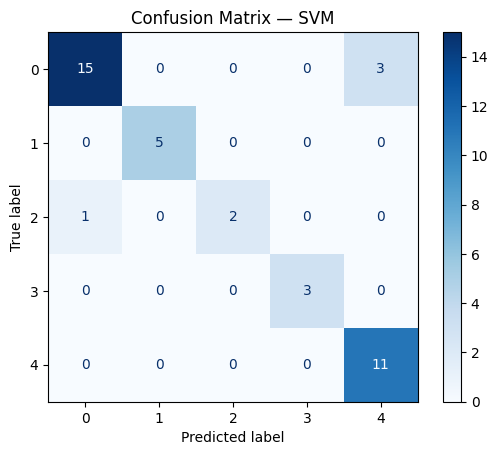

In [21]:
# SVM 
svm_model = SVC(
    kernel='rbf',        
    C=1.0,               
    gamma='scale',      
    random_state=42
)

svm_model.fit(X_train_scaled, Y_train)
y_pred_svm = svm_model.predict(X_test_scaled)

print("=== SVM Evaluation ===")
print("Accuracy:", accuracy_score(Y_test, y_pred_svm))
print("\nClassification Report:")
print(classification_report(Y_test, y_pred_svm))

# Confusion Matrix
cm_svm = confusion_matrix(Y_test, y_pred_svm)
disp_svm = ConfusionMatrixDisplay(
    confusion_matrix=cm_svm,
    display_labels=svm_model.classes_
)
disp_svm.plot(cmap='Blues')
plt.title("Confusion Matrix — SVM")
plt.show()

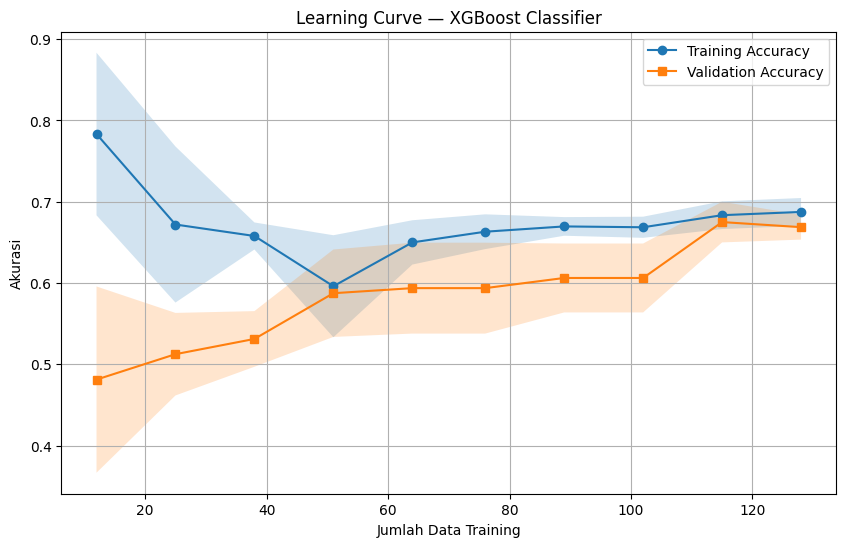

In [22]:
train_sizes, train_scores, val_scores = learning_curve(
    svm_model,
    X_train,
    Y_train,
    cv=5,
    scoring='accuracy',
    train_sizes=np.linspace(0.1, 1.0, 10)
)

train_mean = np.mean(train_scores, axis=1)
train_std  = np.std(train_scores, axis=1)
val_mean   = np.mean(val_scores, axis=1)
val_std    = np.std(val_scores, axis=1)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_mean, marker='o', label='Training Accuracy')
plt.plot(train_sizes, val_mean, marker='s', label='Validation Accuracy')

plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.fill_between(train_sizes, val_mean - val_std, val_mean + val_std, alpha=0.2)

plt.title("Learning Curve — XGBoost Classifier")
plt.xlabel("Jumlah Data Training")
plt.ylabel("Akurasi")
plt.grid(True)
plt.legend()
plt.show()

In [23]:
def evaluate_model(model, X_test, Y_test):
    y_pred = model.predict(X_test)
    return {
        "Accuracy" : accuracy_score(Y_test, y_pred),
        "Precision": precision_score(Y_test, y_pred, average='weighted'),  # ganti binary → weighted
        "Recall"   : recall_score(Y_test, y_pred, average='weighted'),
        "F1 Score" : f1_score(Y_test, y_pred, average='weighted'),
    }

In [24]:
results = []

# Logistic Regression
results.append({
    "Model": "Logistic Regression",
    **evaluate_model(log_model, X_test_scaled, Y_test)
})

# KNN
results.append({
    "Model": "KNN",
    **evaluate_model(knn_model, X_test_scaled, Y_test)
})

# Decision Tree
results.append({
    "Model": "Decision Tree",
    **evaluate_model(dt_model, X_test, Y_test)
})

# Random Forest
results.append({
    "Model": "Random Forest",
    **evaluate_model(rf_model, X_test, Y_test)
})

# XGBoost
results.append({
    "Model": "XGBoost",
    **evaluate_model(xgb_model, X_test, Y_test)
})

# SVM
results.append({
    "Model": "SVM",
    **evaluate_model(svm_model, X_test_scaled, Y_test)
})

C:\Users\acer\AppData\Roaming\Python\Python313\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
comparison_df = pd.DataFrame(results)
comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Logistic Regression,0.900,0.906250,0.900,0.899286
1,KNN,0.600,0.512500,0.600,0.535714
2,Decision Tree,0.975,0.976316,0.975,0.974743
3,Random Forest,0.950,0.951316,0.950,0.947838
4,XGBoost,0.950,0.957566,0.950,0.950139
5,SVM,0.900,0.912946,0.900,0.899059


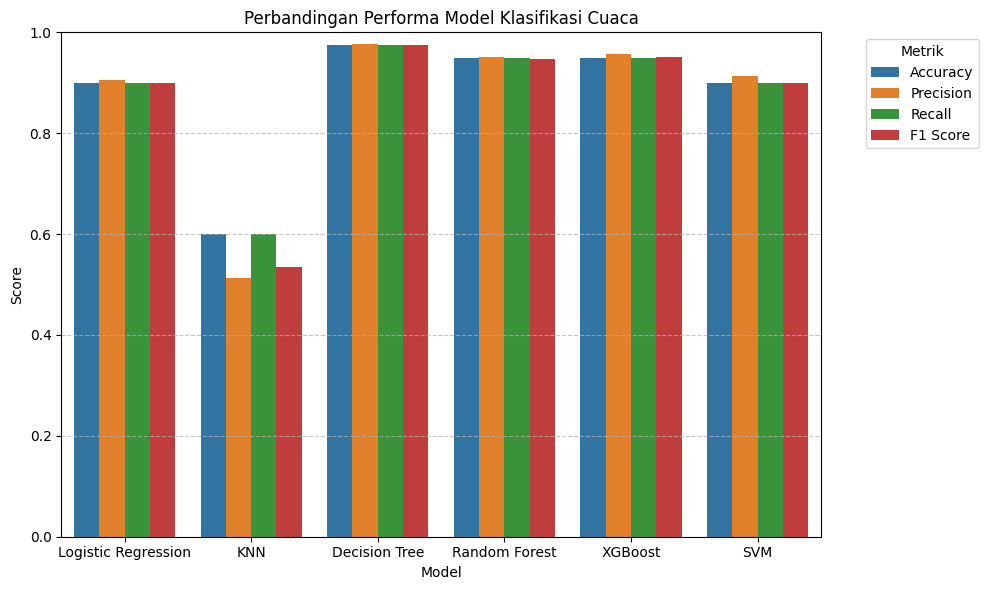

In [26]:
df_melt = comparison_df.melt(
    id_vars='Model',
    var_name='Metric',
    value_name='Score'
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=df_melt,
    x='Model',
    y='Score',
    hue='Metric'
)

plt.title("Perbandingan Performa Model Klasifikasi Cuaca")
plt.ylabel("Score")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.legend(title="Metrik", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()
plt.show()